#### *IMAGE AS AN ARRAY*

In [2]:
import numpy as np
import imageio.v3 as iio
import matplotlib.pyplot as plt

Image shape: (609, 474, 4), dtype: uint8, min: 0, max: 255


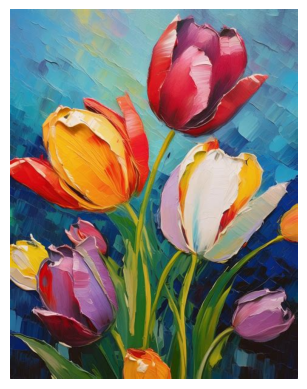

In [ ]:
img = iio.imread("tulips.png")
print(f"Image shape: {img.shape}, dtype: {img.dtype}, min: {img.min()}, max: {img.max()}")

plt.imshow(img)
plt.axis('off') 
plt.show()

In [6]:
arr = np.array(img)
arr.shape, arr.dtype, arr.min(), arr.max()

((609, 474, 4), dtype('uint8'), np.uint8(0), np.uint8(255))

##### **Why are images (H, W, C) and not (C, H, W)?**
---
HWC is how images are naturally stored/scanned; CHW is how ML frameworks prefer to compute. A camera sensor/image file scans pixel by pixel from left to right, top to bottom. For each pixel, it stores all its channels together - R, G, B - before moving to the next pixel.

- (H, W, C) represents for each spatial location, the channels sit next to each other in memory.

But when doing convolutions (using an ML framework like Pytorch), we're applying the same operation independently to each channel. It is computationally more efficient to have all Reds together, all Greens together, then all Blue together, because:

- Convolution operations can process one entire channel as a contiguous memory block (better cache locality, better for vectorized/SIMD or GPU operations)
- GPU kernels are optimized to stride through contiguous chunks of memory efficiently; interleaved RGB data means jumping around more

In [8]:
# accessing pixel(0, 0)
pix0_0 = arr[0, 0] # accessing pixel values at (0, 0) = top left corner of the image
print(f"Pixel (0, 0): {pix0_0}")

Pixel (0, 0): [ 70 147 191 255]


#### **If channels are 3 - R, G, B; what is this 4th channel here?**
---
The 4th value is the "alpha channel" - transparency. Hence, this image is not RGB, but RGBA. In the above example,

- R = 70 (Red intensity)
- G = 147 (Green intensity)
- B = 191 (Blue intensity)
- A = 255 (alpha/opacity -> fully opaque) [0=fully transparent]

PNG files support an extra, optional channel (JPEGs don't - they always have 3-channel RGB, no transparency).

In [10]:
# Checking channel ranges across the whole image
print(f"Red channel range: {arr[:, :, 0].min()} to {arr[:, :, 0].max()}")
print(f"Green channel range: {arr[:, :, 1].min()} to {arr[:, :, 1].max()}")
print(f"Blue channel range: {arr[:, :, 2].min()} to {arr[:, :, 2].max()}")
print(f"Alpha channel range: {arr[:, :, 3].min()} to {arr[:, :, 3].max()}")

Red channel range: 0 to 255
Green channel range: 0 to 255
Blue channel range: 0 to 255
Alpha channel range: 255 to 255


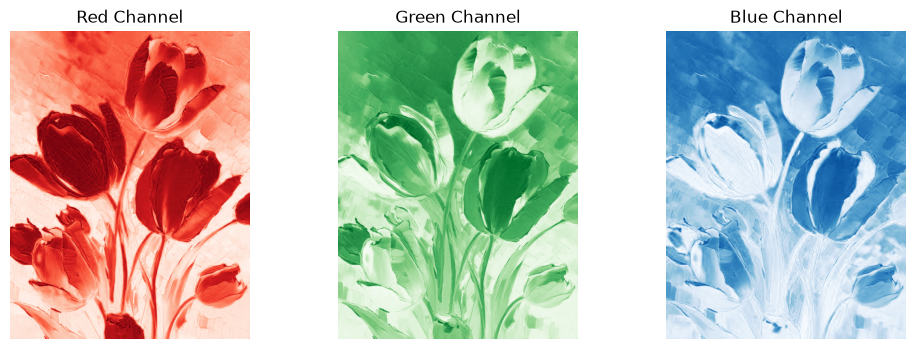

In [ ]:
# Only keeping 3 RGB channels as alpha channel is unused in the image
rgb_arr = arr[:, :, :3]

# Extracting the individual channels
red_channel = rgb_arr[:, :, 0]
green_channel = rgb_arr[:, :, 1]
blue_channel = rgb_arr[:, :, 2]

# Displaying the individual channels
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(red_channel, cmap='Reds')
plt.title('Red Channel')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(green_channel, cmap='Greens')
plt.title('Green Channel')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(blue_channel, cmap='Blues')
plt.title('Blue Channel')
plt.axis('off')
plt.show()

In [30]:
rgb_arr_T = rgb_arr.transpose(2, 0, 1)
print(f"Original RGB array shape: {rgb_arr.shape}, Transposed RGB array shape: {rgb_arr_T.shape}")
print(f"Original RGB array strides: {rgb_arr.strides}")
print(f"Transposed RGB array strides: {rgb_arr_T.strides}")

Original RGB array shape: (609, 474, 3), Transposed RGB array shape: (3, 609, 474)
Original RGB array strides: (1896, 4, 1)
Transposed RGB array strides: (1, 1896, 4)


##### *'A C-contiguous (H,W,C) array stores pixels row-by-row. Strides matter: accessing channel data is a stride-2 hop across memory, which foreshadows why PyTorch defaults to (C,H,W) for cache performance.'* **- What does this statement mean?**
---
Strides tell us: "how many bytes do I skip to move one step along this axis?"

- channel axis stride: 1 -> each channel value is 1 byte (uint8 -> 0-255)
- width axis stride: 4 -> to move to the next pixel, move 4 bytes
- height axis stride: 1896 -> to move to the next row, skip 1896 bytes

***NOTE: If each pixel had exactly 3 channels tightly packed, moving to the next pixel should cost 3 bytes, not 4. This means the RGB array was sliced from an RGBA array. NumPy doesn't copy or repack the data.***


In [32]:
print(rgb_arr.flags['C_CONTIGUOUS'])

False


In [33]:
img_clean = np.ascontiguousarray(rgb_arr)
img_clean.strides

(1422, 3, 1)

Transposed: shape (3, 609, 474), strides (1, 1896, 4).    
Transpose doesn't move data in memory, just relabels the axes. 

The `False` printed by `print(rgb_arr.flags['C_CONTIGUOUS'])` proves that the array's memory layout is messy (leftover from an RGBA slicing, not a clean packed RGB block). Hence we did `img_clean = np.ascontiguousarray(rgb_arr)` - it forces numpy to actually copy the data into a tidy, contagious 3-channel layout.

In [ ]:
# Timing a repeated heavy operation on each array to see the performance difference between them
import time

rgb_view = rgb_arr.T # Non-contiguous view
rgb_clean = img_clean # Contiguous array

start = time.time()
for _ in range(100):
    result = rgb_view.sum()
print("Non-contiguous time:", time.time() - start)

start = time.time()
for _ in range(100):
    result = rgb_clean.sum()
print("Contiguous time:", time.time() - start)

Non-contiguous time: 0.24412941932678223
Contiguous time: 0.07428741455078125


##### **What does non-contiguous actually cost us?**
---
When memory is contiguous, the CPU can read a whole chunk in one go. Let's say it pulls in 64 bytes at a time into cache (`cache line`) - all of those bytes are useful, adjacent data.  
But when memory is non-contiguous, the CPU pulls in the same 64-byte cache line, but every 4th byte is now "junk" (the skipped alpha byte). So, a chunk of the data loaded into fast acche memory is wasted.
`=> more cache misses, more trips to slower RAM, more overhead -> even though the number of useful values being processed are identical.`

It really matters when:
- `large arrays + heavy repeated operations`: matrix multiplication, convolutions, big elementwise math across the whole array -> here the stride overhead adds up and is genuinely measurable.
- `feeding into other libraries/GPU code`: many optimized backends (cuDNN etc) either require contiguous input or silently make a hidden copy for us -> meaning the extra "cleaning" cost is paid anyway, just invisibly and repeatedly instead of once explicitly.


---
***"Contiguous memory access patterns being dramatically faster than scattered access" is the core principle behind writing fast CUDA/kernel code.***

*GPU kernels are extremely sensitive to memory access patterns (called `memory coalescing` in GPU programming). This small concept of NumPy strides is a small, safe preview of a concept that becomes make-or-break when writing actual kernels.*

Grayscale image shape: (609, 474), dtype: float64, min: 1.4667000000000001, max: 253.7789


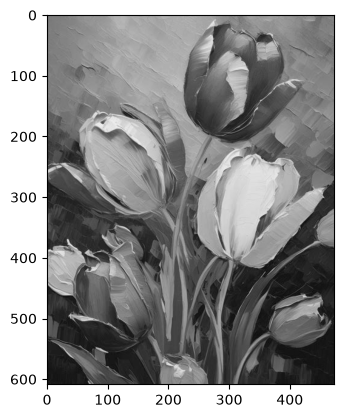

In [ ]:
# Convert the image to grayscale

gray_arr = np.dot(rgb_arr, [0.2989, 0.5870, 0.1140]) # dot product of (609, 474, 3) and (3,) = (609, 474)

print(f"Grayscale image shape: {gray_arr.shape}, dtype: {gray_arr.dtype}, min: {gray_arr.min()}, max: {gray_arr.max()}")
plt.imshow(gray_arr, cmap='gray')

c:\Users\aktkr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\aktkr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Blurred shape: (579, 444)


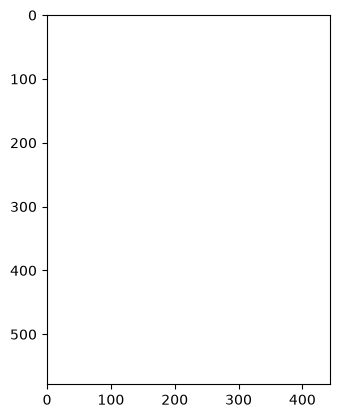

In [44]:
# Blur the image using a simple averaging filter

# Approach 1: blurring using a 3x3 kernel
def box_blur_naive(img, k=3):
    """Apply a simple box blur using naive approach"""
    H, W = img.shape
    center_h, center_w = H // 2, W // 2
    region_size = 150
    half_region = region_size // 2
    middle_crop = img[center_h - half_region: center_h + half_region,
                      center_w - half_region: center_w + half_region]

    pad = k // 2
    out = np.zeros((H-2*pad, W-2*pad))
    for i in range(pad, H-pad):
        for j in range(pad, W-pad):
            window = middle_crop[i-pad:i+pad+1, j-pad:j+pad+1]
            out[i-pad, j-pad] = np.mean(window)
    return out

blurred_middle = box_blur_naive(gray_arr, k=30)
print("Blurred shape:", blurred_middle.shape)
plt.imshow(blurred_middle, cmap='gray')


In [39]:
img = gray_arr.copy()
H, W = img.shape
center_h, center_w = H // 2, W // 2
region_size = 150
half_region = region_size // 2
middle_crop = img[center_h - half_region: center_h + half_region,
                    center_w - half_region: center_w + half_region]

print(f"Middle crop shape: {middle_crop.shape}")

Middle crop shape: (150, 150)


***Blurring: replacing each pixel with an average of its neighbourhood***  
*It makes each pixel "leak" a bit of its value into its neighbours, and take a bit of value from them in return. The result is that sudden changes get softened into gradual ones.*